In [115]:
from pathlib import Path

import pandas as pd
from pandas import DataFrame

from caveat.evaluate.describe.frequency import frequency_plots
from caveat.evaluate.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from caveat.evaluate.describe.transitions import sequence_prob_plot

In [116]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_paths = {
    "DiscFF": Path("../logs/vae_paper/DiscFF"),
    "DiscCNN": Path("../logs/vae_paper/DiscCNN"),
    "DiscRNN": Path("../logs/vae_paper/DiscCNN"),
    "ContFF": Path("../logs/vae_paper/ContFF"),
    "ContCNN": Path("../logs/vae_paper/ContCNN"),
    "ContRNN": Path("../logs/vae_paper/ContRNN"),
}
target_schedules = pd.read_csv("../tmp/nts_schedules_2023.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


next(find_nth(Path("../logs/paper_d_rnn")))

('DiscLSTM5', PosixPath('../logs/paper_d_rnn/DiscLSTM5/version_1'))

In [117]:
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}

In [118]:
def domain_distances(batch_paths, suffix=""):
    distances_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / f"domain_distances{suffix}.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "dist")] = distances[columns].mean(axis=1)
        variances_combined[(name, "var")] = distances[columns].var(axis=1)

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    return distances_combined


df = domain_distances(batch_paths, suffix="")
print(df[::-1].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrrrr}
\toprule
 & dist & dist & dist & dist & dist & dist \\
domain &  &  &  &  &  &  \\
\midrule
aggregate & 0.005 & 0.006 & 0.006 & 0.014 & 0.012 & 0.009 \\
count & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\
creativity & 0.284 & 0.313 & 0.313 & 0.082 & 0.179 & 0.017 \\
participations & 0.152 & 0.162 & 0.162 & 0.062 & 0.046 & 0.064 \\
sample quality & 0.000 & 0.000 & 0.000 & 0.057 & 0.030 & 0.018 \\
timing & 0.051 & 0.044 & 0.044 & 0.056 & 0.055 & 0.025 \\
transitions & 0.008 & 0.006 & 0.006 & 0.004 & 0.005 & 0.004 \\
\bottomrule
\end{tabular}



,DiscFF,DiscCNN,DiscRNN,ContFF,ContCNN,ContRNN
,dist,dist,dist,dist,dist,dist
domain,,,,,,
aggregate,0.005273,0.005886,0.005886,0.013543,0.012246,0.008588
count,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
creativity,0.284242,0.312884,0.312884,0.081955,0.179218,0.017146
participations,0.152095,0.162393,0.162393,0.061814,0.045899,0.063894
sample quality,0.000309,0.000000,0.000000,0.057196,0.030299,0.018193
timing,0.050741,0.043837,0.043837,0.055525,0.054676,0.025205
transitions,0.008437,0.006389,0.006389,0.004049,0.004828,0.003823


In [ ]:
def distribution_distances(batch_paths):
    distances_combined = pd.DataFrame()
    descriptions_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(path / "feature_distances.csv").set_index(
            ["domain", "feature"]
        )
        descriptions = pd.read_csv(path / "feature_descriptions.csv").set_index(
            ["domain", "feature"]
        )

        columns = set(distances.columns)
        columns = list(columns - set(["observed", "unit", "mean", "std"]))

        distances_combined[(name, "mean")] = distances[columns].mean(axis=1)
        variances_combined[(name, "std")] = distances[columns].std(axis=1)
        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    # distances_combined[("Observed", "")] = distances["observed"]
    # distances_combined[("unit", "")] = distances["unit"]

    order = list(distances_combined.columns)
    # order.pop(order.index(("Observed", "")))

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return (
        distances_combined.loc[index, order],
        variances_combined,
        descriptions_combined.loc[index, order],
    )


dist, vars, desc = distribution_distances(batch_paths)
# print(dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))
display(dist)
display(desc)

                            DiscFF_nrun0  DiscFF_nrun3  DiscFF_nrun2  \
domain     feature                                                     
aggregate  agg. frequency       0.004403      0.008145      0.004084   
count      total schedules      0.000000      0.000000      0.000000   
creativity conservatism         0.114551      0.104113      0.093042   

                            DiscFF_nrun4  DiscFF_nrun1  
domain     feature                                      
aggregate  agg. frequency       0.005264      0.004468  
count      total schedules      0.000000      0.000000  
creativity conservatism         0.098151      0.092242  
                            DiscFF_nrun0  DiscFF_nrun3  DiscFF_nrun2  \
domain     feature                                                     
aggregate  agg. frequency       0.683876      0.713759      0.674830   
count      total schedules  59265.000000  59265.000000  59265.000000   
creativity diversity            0.502438      0.478748      0.5904

DiscFF   DiscCNN   DiscRNN  \
                                            mean      mean      mean   
domain         feature                                                 
creativity     conservatism             0.100420  0.118332  0.118332   
               homogeneity              0.468064  0.507436  0.507436   
sample quality consecutive              0.000000  0.000000  0.000000   
               invalid                  0.000309  0.000000  0.000000   
               not home based           0.000309  0.000000  0.000000   
aggregate      agg. frequency           0.005273  0.005886  0.005886   
participations lengths                  0.362578  0.398694  0.398694   
               pair participation rate  0.014246  0.010823  0.010823   
               participation rate       0.079460  0.077663  0.077663   
transitions    2-gram                   0.019597  0.014544  0.014544   
               3-gram                   0.003706  0.002820  0.002820   
               4-gram                   0.002008  0.001803  0.001803   
timing         durations                0.038563  0.033691  0.033691   
               joint-durations          0.069706  0.056699  0.056699   
               start times              0.021509  0.017584  0.017584   
               start-durations          0.073185  0.067376  0.067376   

                                          ContFF   ContCNN   ContRNN  
                                            mean      mean      mean  
domain         feature                                                
creativity     conservatism             0.010808  0.010386  0.012104  
               homogeneity              0.153102  0.348050  0.022188  
sample quality consecutive              0.027561  0.024863  0.017694  
               invalid                  0.057196  0.030299  0.018193  
               not home based           0.032319  0.005495  0.000507  
aggregate      agg. frequency           0.013543  0.012246  0.008588  
participations lengths                  0.140440  0.100289  0.154408  
               pair participation rate  0.005143  0.004733  0.003939  
               participation rate       0.039859  0.032677  0.033335  
transitions    2-gram                   0.009335  0.010018  0.008133  
               3-gram                   0.001627  0.002539  0.001924  
               4-gram                   0.001185  0.001927  0.001412  
timing         durations                0.040600  0.038671  0.016155  
               joint-durations          0.078161  0.075161  0.037689  
               start times              0.032442  0.033016  0.015942  
               start-durations          0.070899  0.071854  0.031032

DiscFF   DiscCNN   DiscRNN  \
                                            mean      mean      mean   
domain         feature                                                 
creativity     diversity                0.531936  0.492564  0.492564   
               novelty                  0.899580  0.881668  0.881668   
sample quality consecutive              0.000000  0.000000  0.000000   
               invalid                  0.000309  0.000000  0.000000   
               not home based           0.000309  0.000000  0.000000   
aggregate      agg. frequency           0.688378  0.684172  0.684172   
participations lengths                  3.811282  3.495574  3.495574   
               pair participation rate  0.044826  0.035591  0.035591   
               participation rate       0.476410  0.436947  0.436947   
transitions    2-gram                   0.057949  0.052225  0.052225   
               3-gram                   0.006945  0.006294  0.006294   
               4-gram                   0.002385  0.002241  0.002241   
timing         durations                0.263062  0.286174  0.286174   
               joint-durations          0.395319  0.447549  0.447549   
               start times              0.428302  0.409472  0.409472   
               start-durations          0.695772  0.700249  0.700249   

                                          ContFF   ContCNN   ContRNN  
                                            mean      mean      mean  
domain         feature                                                
creativity     diversity                0.846898  0.651950  0.977812  
               novelty                  0.989192  0.989614  0.987896  
sample quality consecutive              0.027561  0.024863  0.017694  
               invalid                  0.057196  0.030299  0.018193  
               not home based           0.032319  0.005495  0.000507  
aggregate      agg. frequency           0.619807  0.641150  0.631839  
participations lengths                  3.894383  3.940359  3.840142  
               pair participation rate  0.039647  0.041062  0.039990  
               participation rate       0.486798  0.492545  0.480018  
transitions    2-gram                   0.046746  0.061937  0.048130  
               3-gram                   0.004982  0.009577  0.006278  
               4-gram                   0.002018  0.004292  0.002477  
timing         durations                0.256834  0.253834  0.260462  
               joint-durations          0.429024  0.422315  0.436733  
               start times              0.434009  0.433921  0.429090  
               start-durations          0.692812  0.689691  0.691530

In [120]:
def get_descriptions(batch_paths):
    combi_desc = pd.DataFrame()
    combi_dist = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions.csv").set_index(
            ["domain", "feature", "segment"]
        )
        distances = pd.read_csv(path / "distances.csv").set_index(
            ["domain", "feature", "segment"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "unit", "mean", "std", "feature count"])
            - weights
        )

        combi_desc[name, "mean"] = descriptions[columns].mean(axis=1)
        combi_dist[name, "mean"] = distances[columns].mean(axis=1)
        # descriptions_combined[name, "var"] = descriptions[columns].var(axis=1)
        # combined[name, "EMD"] = distances[columns].mean(axis=1)

    combi_desc["weight", ""] = distances["observed__weight"]
    combi_desc["Observed", ""] = descriptions["observed"]
    combi_desc["unit", ""] = descriptions["unit"]

    combi_dist["weight", ""] = distances["observed__weight"]
    combi_dist["Observed", ""] = descriptions["observed"]
    combi_dist["unit", ""] = descriptions["unit"]

    combi_desc.columns = pd.MultiIndex.from_tuples(combi_desc.columns)
    combi_dist.columns = pd.MultiIndex.from_tuples(combi_dist.columns)

    combi_desc = combi_desc.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(
        lambda x: x.sort_values(
            [("weight", ""), ("Observed", "")], ascending=False
        ).head(20)
    )
    combi_desc = combi_desc.drop(("weight", ""), axis=1)

    order = list(combi_desc.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "aggregate",
        "participations",
        "transitions",
        "timing",
        "sample quality",
        "creativity",
    ]

    return combi_desc.loc[index, order], combi_dist.loc[index, order]


descriptions, distances = get_descriptions(batch_paths)

In [121]:
distances.loc["participations", :]

Observed    DiscFF   DiscCNN  \
                                                        mean      mean   
feature                 segment                                          
lengths                 sequence lengths  3.893647  0.362578  0.398694   
participation rate      education         0.089581  0.042183  0.026481   
                        escort            0.256070  0.109191  0.149096   
                        home              2.306133  0.163449  0.218517   
                        medical           0.042858  0.023184  0.016276   
...                                            ...       ...       ...   
pair participation rate escort+work       0.000894  0.000894  0.000675   
                        medical+shop      0.000101  0.000101  0.000483   
                        visit+work        0.000101  0.000101  0.000607   
                        medical+work      0.000051  0.000051  0.000513   
                        medical+visit     0.000000  0.000000  0.000003   

                                           DiscRNN    ContFF   ContCNN  \
                                              mean      mean      mean   
feature                 segment                                          
lengths                 sequence lengths  0.398694  0.140440  0.100289   
participation rate      education         0.026481  0.021028  0.014568   
                        escort            0.149096  0.057606  0.063123   
                        home              0.218517  0.056563  0.047087   
                        medical           0.016276  0.010974  0.009236   
...                                            ...       ...       ...   
pair participation rate escort+work       0.000675  0.000803  0.000861   
                        medical+shop      0.000483  0.000101  0.000101   
                        visit+work        0.000607  0.000091  0.000101   
                        medical+work      0.000513  0.000051  0.000051   
                        medical+visit     0.000003  0.000000  0.000000   

                                           ContRNN      unit  
                                              mean            
feature                 segment                               
lengths                 sequence lengths  0.154408   length.  
participation rate      education         0.025529  av. rate  
                        escort            0.055311  av. rate  
                        home              0.057052  av. rate  
                        medical           0.009314  av. rate  
...                                            ...       ...  
pair participation rate escort+work       0.000624  av rate.  
                        medical+shop      0.000101  av rate.  
                        visit+work        0.000101  av rate.  
                        medical+work      0.000051  av rate.  
                        medical+visit     0.000000  av rate.  

[64 rows x 8 columns]

In [ ]:
distances.loc["transitions", :]

Observed    DiscFF   DiscCNN   DiscRNN  \
                                                 mean      mean      mean   
feature segment                                                             
2-gram  home>other                 0.450335  0.451546  0.451546  0.451546   
        other>home                 0.444130  0.484977  0.484977  0.484977   
        shop>home                  0.246259  0.207751  0.207751  0.207751   
        home>work                  0.238477  0.235415  0.235415  0.235415   
        work>home                  0.227027  0.221342  0.221342  0.221342   
        home>shop                  0.221097  0.192982  0.192982  0.192982   
        home>escort                0.198197  0.214466  0.214466  0.214466   
        escort>home                0.190432  0.189727  0.189727  0.189727   
        visit>home                 0.102484  0.106180  0.106180  0.106180   
        home>visit                 0.094805  0.112090  0.112090  0.112090   
        home>education             0.086337  0.102269  0.102269  0.102269   
        education>home             0.081846  0.095354  0.095354  0.095354   
        home>medical               0.037572  0.033967  0.033967  0.033967   
        other>other                0.034813  0.053018  0.053018  0.053018   
        medical>home               0.034641  0.032024  0.032024  0.032024   
        escort>escort              0.023980  0.013765  0.013765  0.013765   
        shop>shop                  0.021511  0.015000  0.015000  0.015000   
        other>shop                 0.020997  0.019072  0.019072  0.019072   
        escort>other               0.013455  0.019464  0.019464  0.019464   
        other>escort               0.013215  0.007392  0.007392  0.007392   
3-gram  home>other>home            0.394268  0.393409  0.393409  0.393409   
        home>work>home             0.213795  0.206791  0.206791  0.206791   
        home>shop>home             0.190689  0.165128  0.165128  0.165128   
        home>escort>home           0.143313  0.163924  0.163924  0.163924   
        home>education>home        0.079190  0.094859  0.094859  0.094859   
        home>visit>home            0.076070  0.088855  0.088855  0.088855   
        other>home>other           0.051233  0.066201  0.066201  0.066201   
        escort>home>escort         0.038721  0.030569  0.030569  0.030569   
        home>medical>home          0.030596  0.032024  0.032024  0.032024   
        shop>home>other            0.030065  0.029124  0.029124  0.029124   
        home>other>other           0.022883  0.035489  0.035489  0.035489   
        other>other>home           0.022043  0.038940  0.038940  0.038940   
        other>home>shop            0.021289  0.012783  0.012783  0.012783   
        escort>home>other          0.019540  0.024967  0.024967  0.024967   
        work>home>other            0.018855  0.026396  0.026396  0.026396   
        home>escort>escort         0.017483  0.010680  0.010680  0.010680   
        escort>escort>home         0.016866  0.010886  0.010886  0.010886   
        other>shop>home            0.016832  0.015245  0.015245  0.015245   
        home>other>shop            0.016695  0.014325  0.014325  0.014325   
        shop>shop>home             0.016318  0.011504  0.011504  0.011504   
4-gram  other>home>other>home      0.123117  0.148371  0.148371  0.148371   
        home>other>home>other      0.121958  0.135518  0.135518  0.135518   
        home>escort>home>escort    0.086699  0.067376  0.067376  0.067376   
        escort>home>escort>home    0.086565  0.069335  0.069335  0.069335   
        shop>home>other>home       0.073638  0.066640  0.066640  0.066640   
        home>shop>home>other       0.060622  0.051809  0.051809  0.051809   
        home>other>home>shop       0.051039  0.029244  0.029244  0.029244   
        other>home>shop>home       0.049077  0.029077  0.029077  0.029077   
        work>home>other>home       0.046447  0.058776  0.058776  0.058776   
        home>work>home>other   

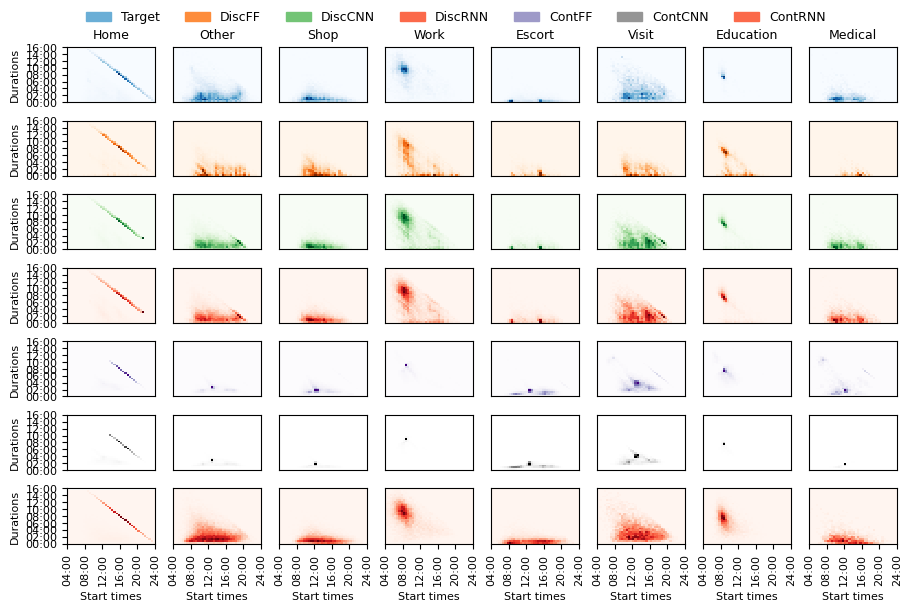

In [123]:
fig = joint_time_distributions_plot(
    target_schedules,
    schedules,
    figsize=(9, 6),
    observed_title="Target",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)

In [ ]:
fig = times_distributions_plot(
    target_schedules, schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    schedules,
    color=cmap,
    figsize=(12, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    target_schedules,
    schedules,
    cmap=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)

In [ ]:
import random

from pam.core import Household, Person
from pam.plot.plans import plot_household

from caveat.data.utils import trace_to_pam


def stretch(schedules):
    return schedules.groupby(schedules.pid).apply(stretcher)


def stretcher(schedule):
    duration = schedule.duration.sum()
    if duration != 1440:
        a = 1440 / duration
        schedule.duration = (schedule.duration * a).astype(int)
        accumulated = list(schedule.duration.cumsum())
        schedule.start = [0] + accumulated[:-1]
        schedule.end = accumulated
    return schedule


def trim(schedules):
    schedules[schedules.end > 1440] = 1440
    schedules[schedules.start > 1440] = 1440
    schedules.duration = schedules.end - schedules.start
    schedules = schedules[schedules.duration > 0]
    return schedules


def pad(schedules):
    return (
        schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
    )


def padder(schedule):
    if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
        pid = schedule.pid.iloc[0]
        schedule = pd.concat(
            [
                schedule,
                DataFrame(
                    {
                        "pid": pid,
                        "start": schedule.end.iloc[-1],
                        "end": 1440,
                        "duration": 1440 - schedule.end.iloc[-1],
                        "act": "home",
                    },
                    index=[0],
                ),
            ]
        )
    elif schedule.end.iloc[-1] < 1440:
        schedule.end.iloc[-1] = 1440
        schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
    return schedule


def plot_schedules(schedules, **kwargs):

    cmap = {
        "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
        "other": (1.0, 1.0, 0.7019607843137254),
        "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
        "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
        "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
        "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
        "education": (
            0.7019607843137254,
            0.8705882352941177,
            0.4117647058823529,
        ),
        "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
        "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
    }
    cmap = {n.title(): c for n, c in cmap.items()}

    hh = Household("")

    pids = schedules.pid
    selected = random.sample(list(pids), 5)
    for i, pid in enumerate(selected):
        person = Person(pid)
        plan = schedules[schedules.pid == pid]
        plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
        mapping = {a: a for a in plan.act}

        trace = [
            (row.act, row.start, row.end, row.duration)
            for i, row in plan.iterrows()
        ]
        plan = trace_to_pam(trace, mapping)

        person = Person(i)
        person.plan = plan
        hh.add(person)

    plot_household(hh, cmap=cmap, width=25)

/tmp/ipykernel_3670060/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_3670060/1738895634.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_3670060/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the groupi

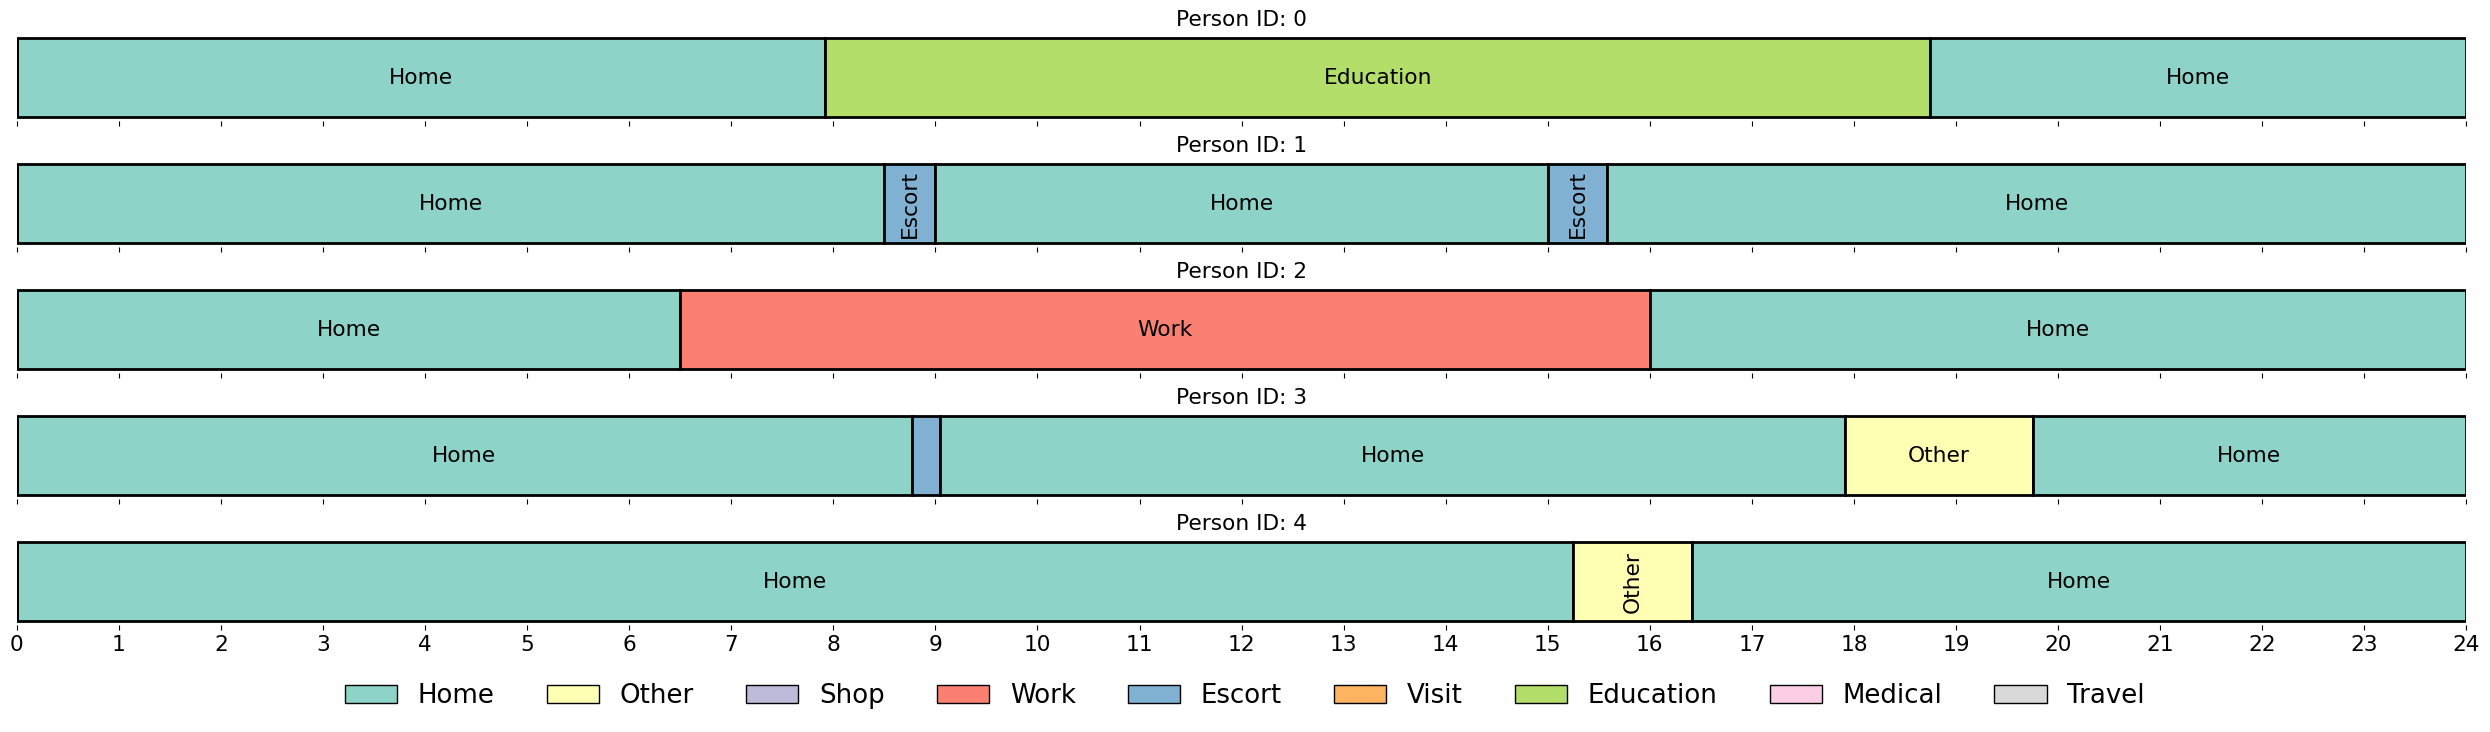

In [ ]:
plot_schedules(target_schedules)

/tmp/ipykernel_3670060/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_3670060/1738895634.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_3670060/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the groupi

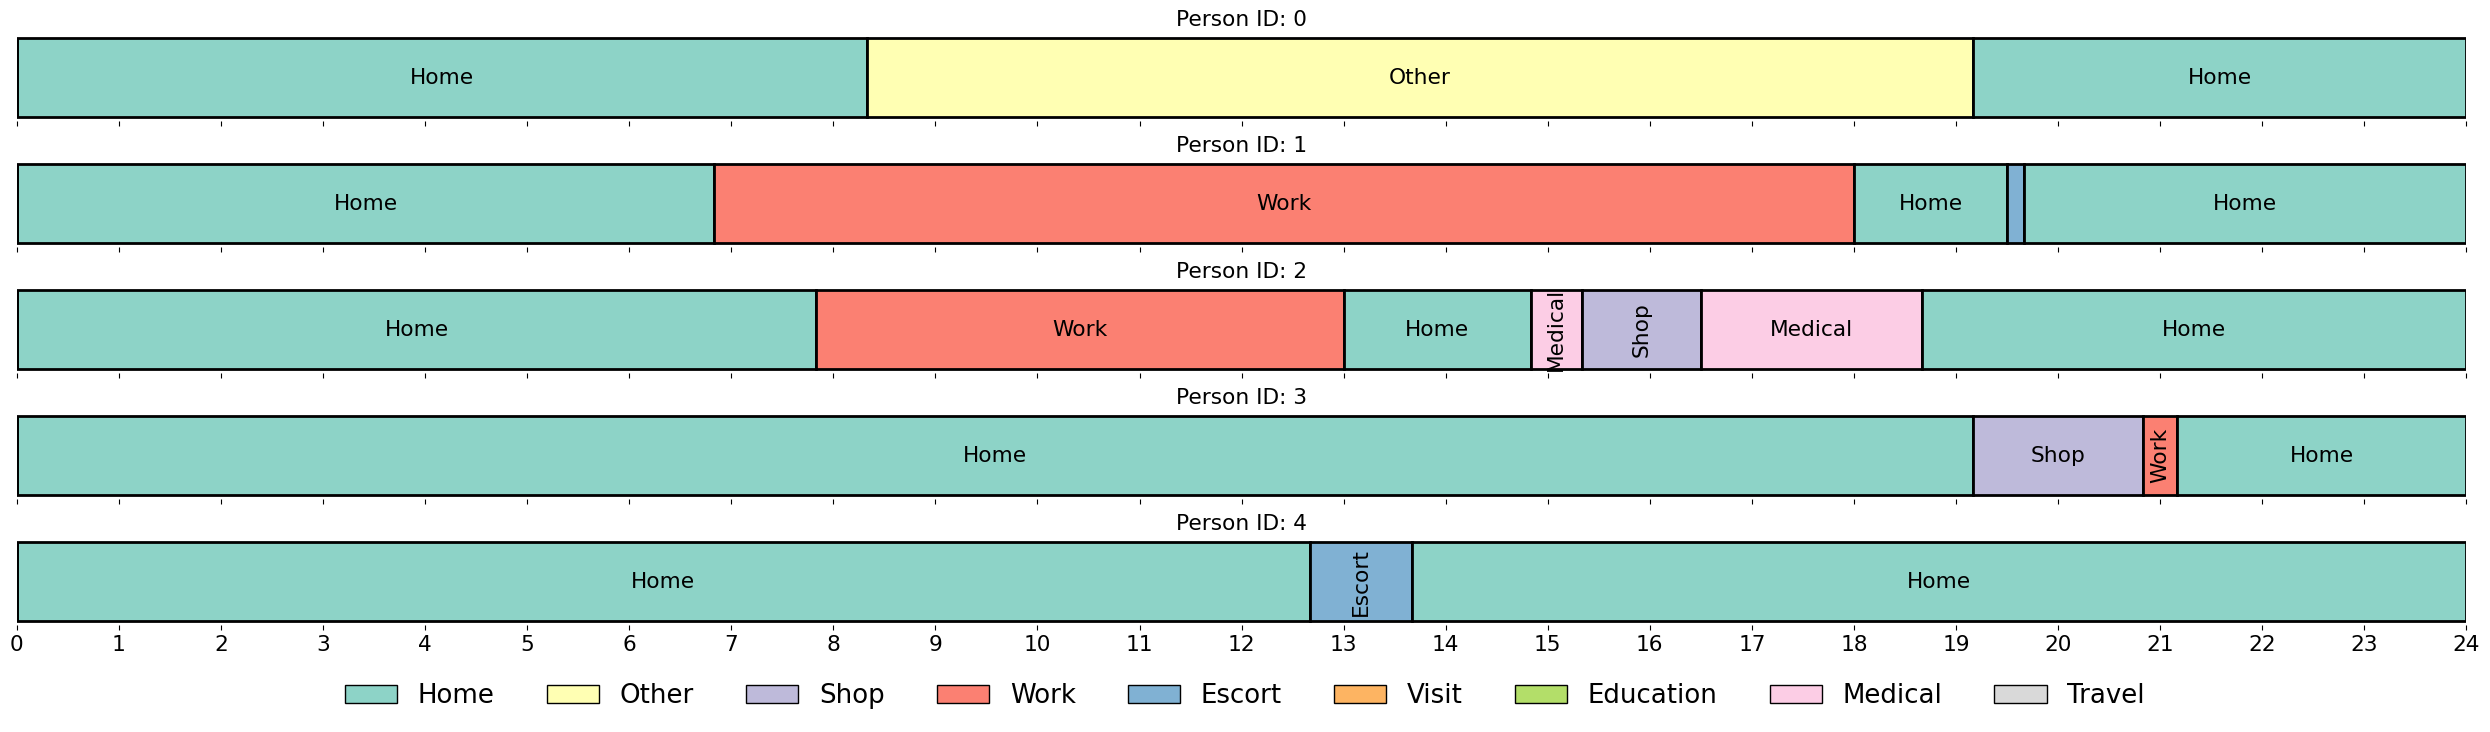

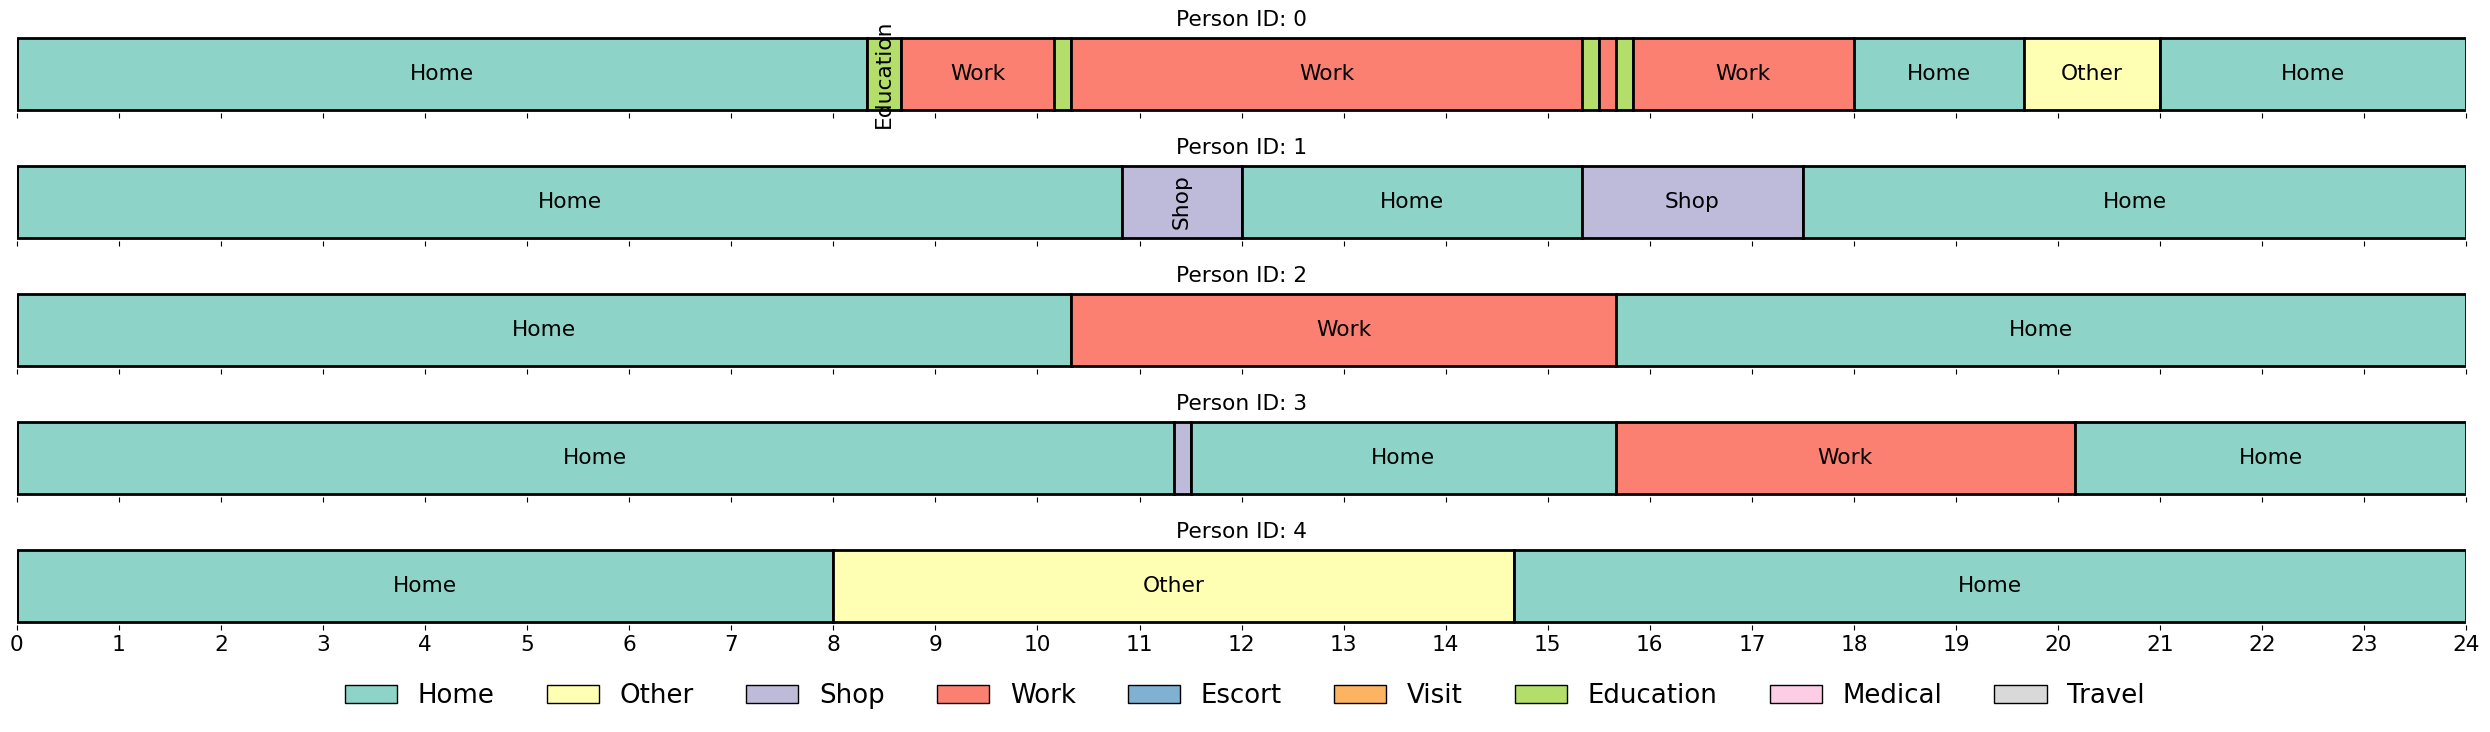

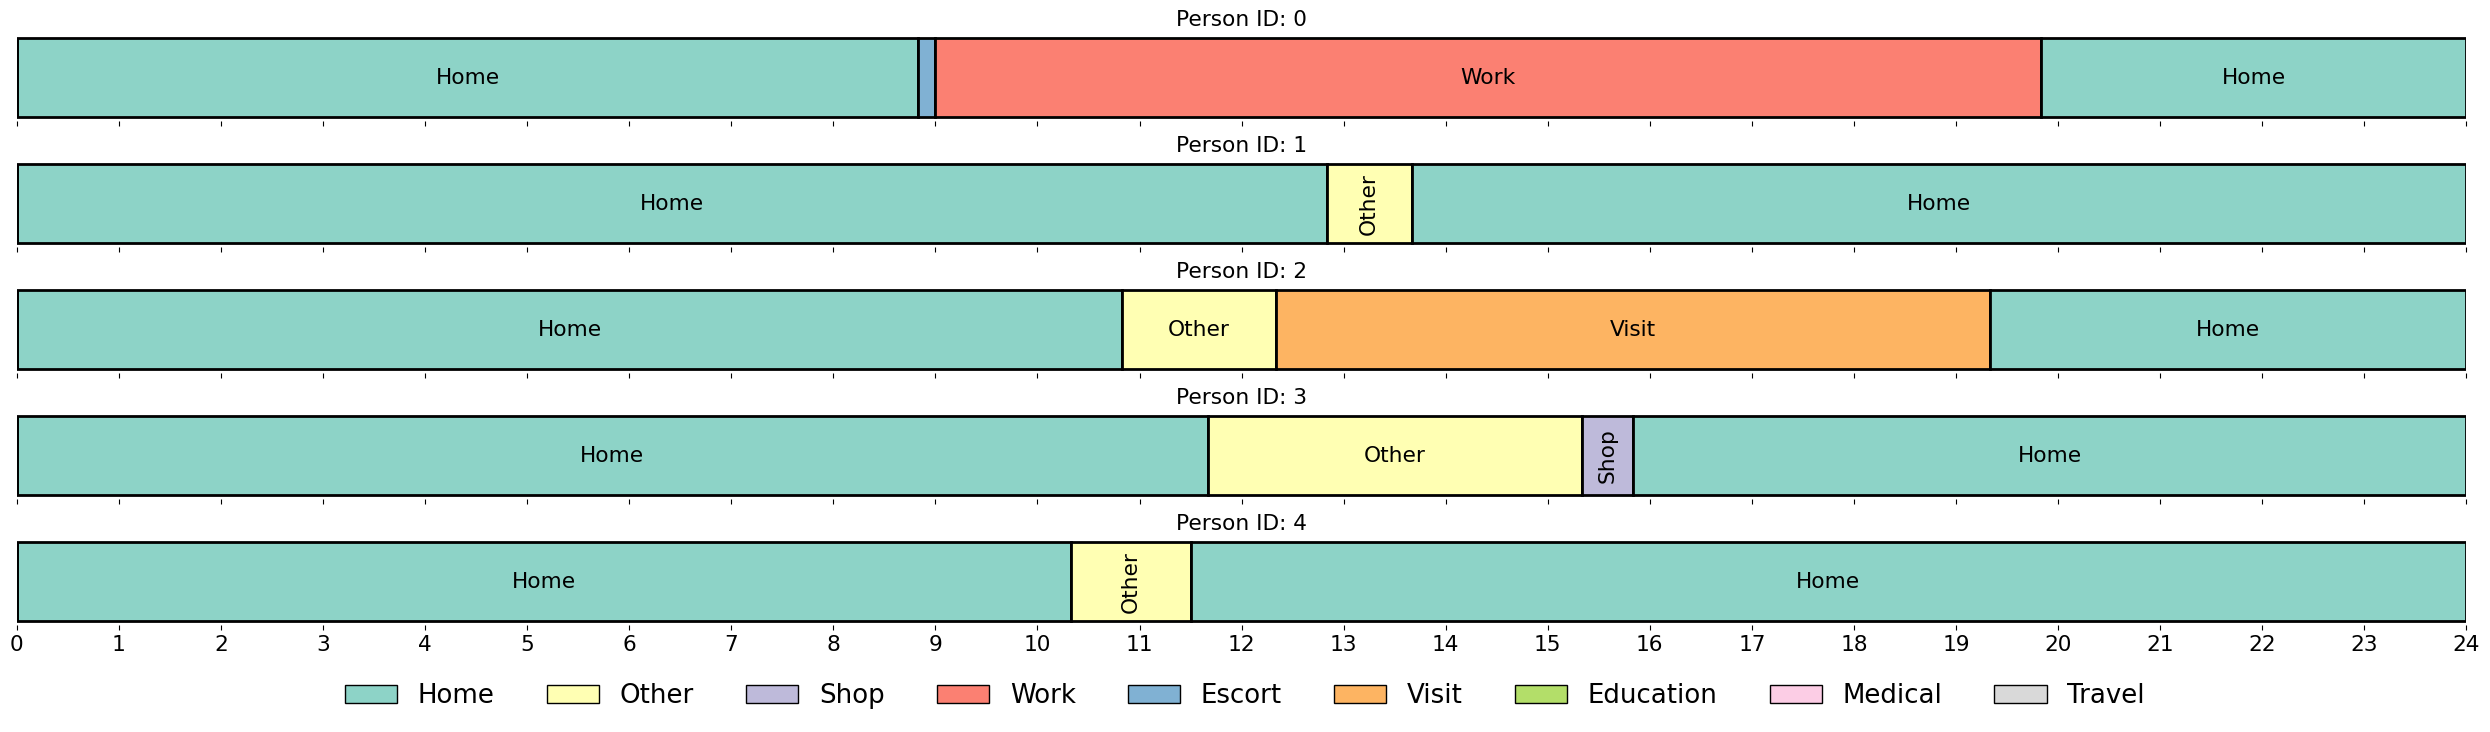

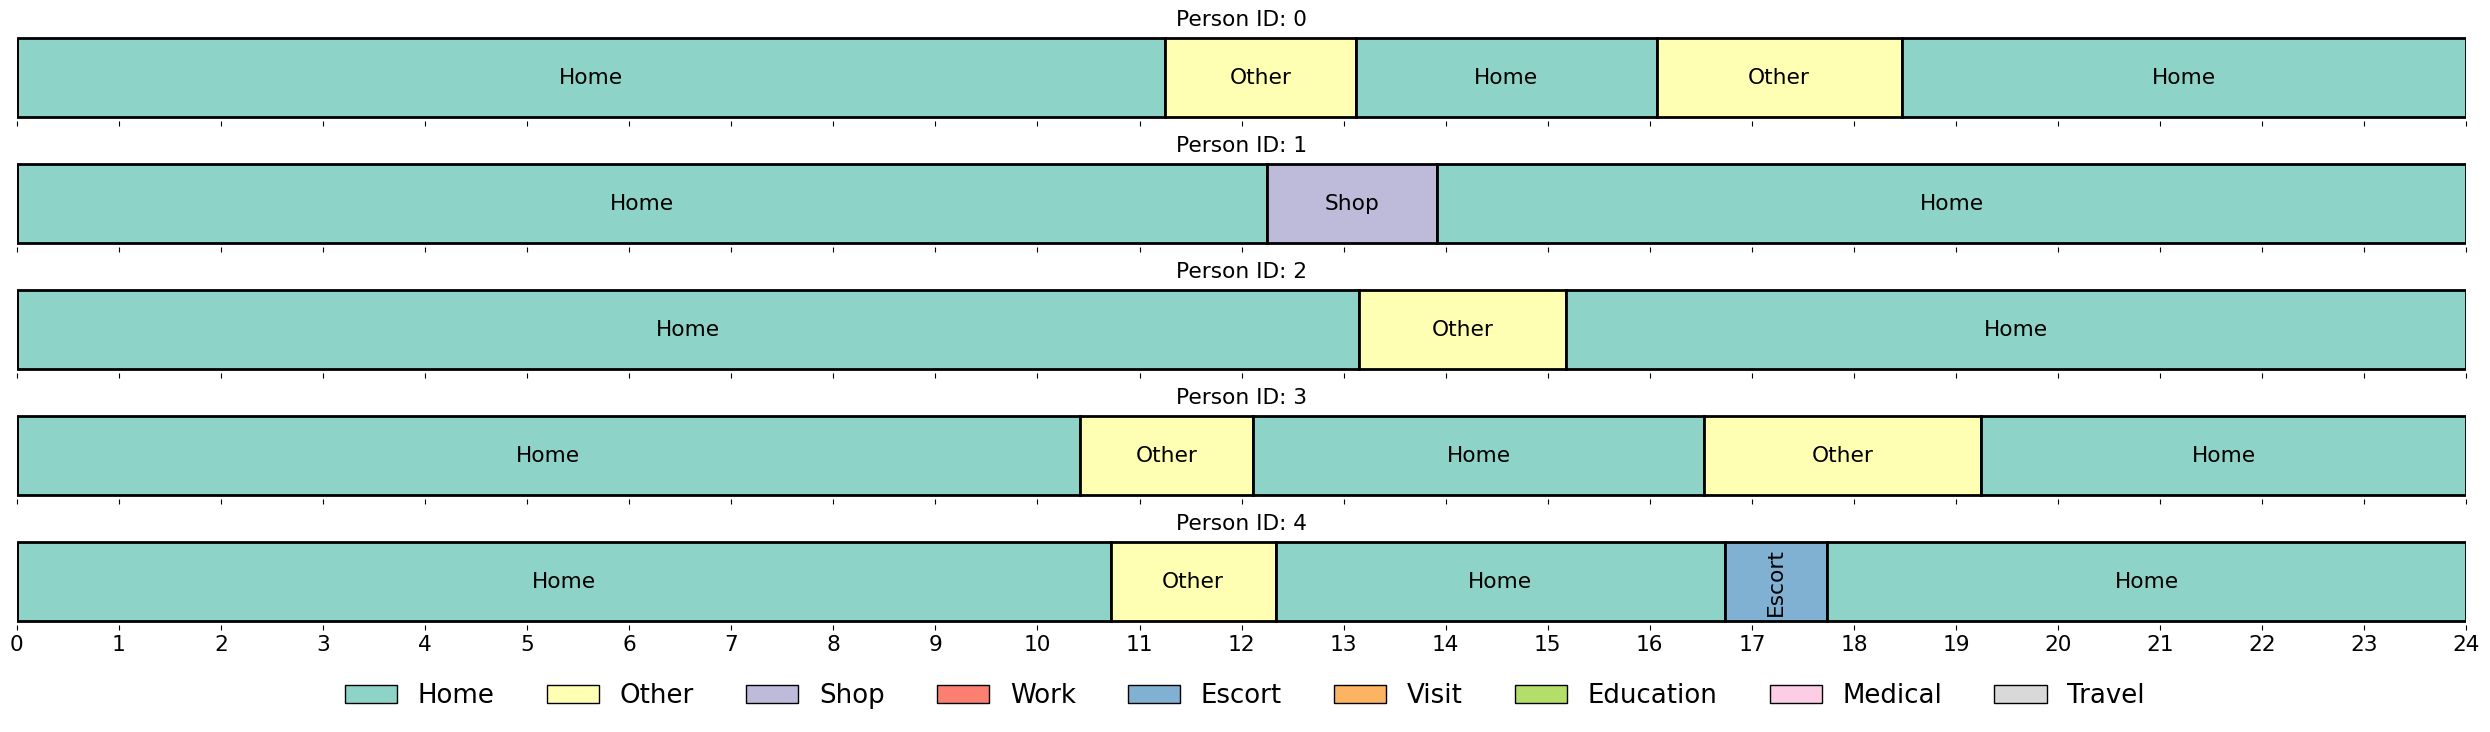

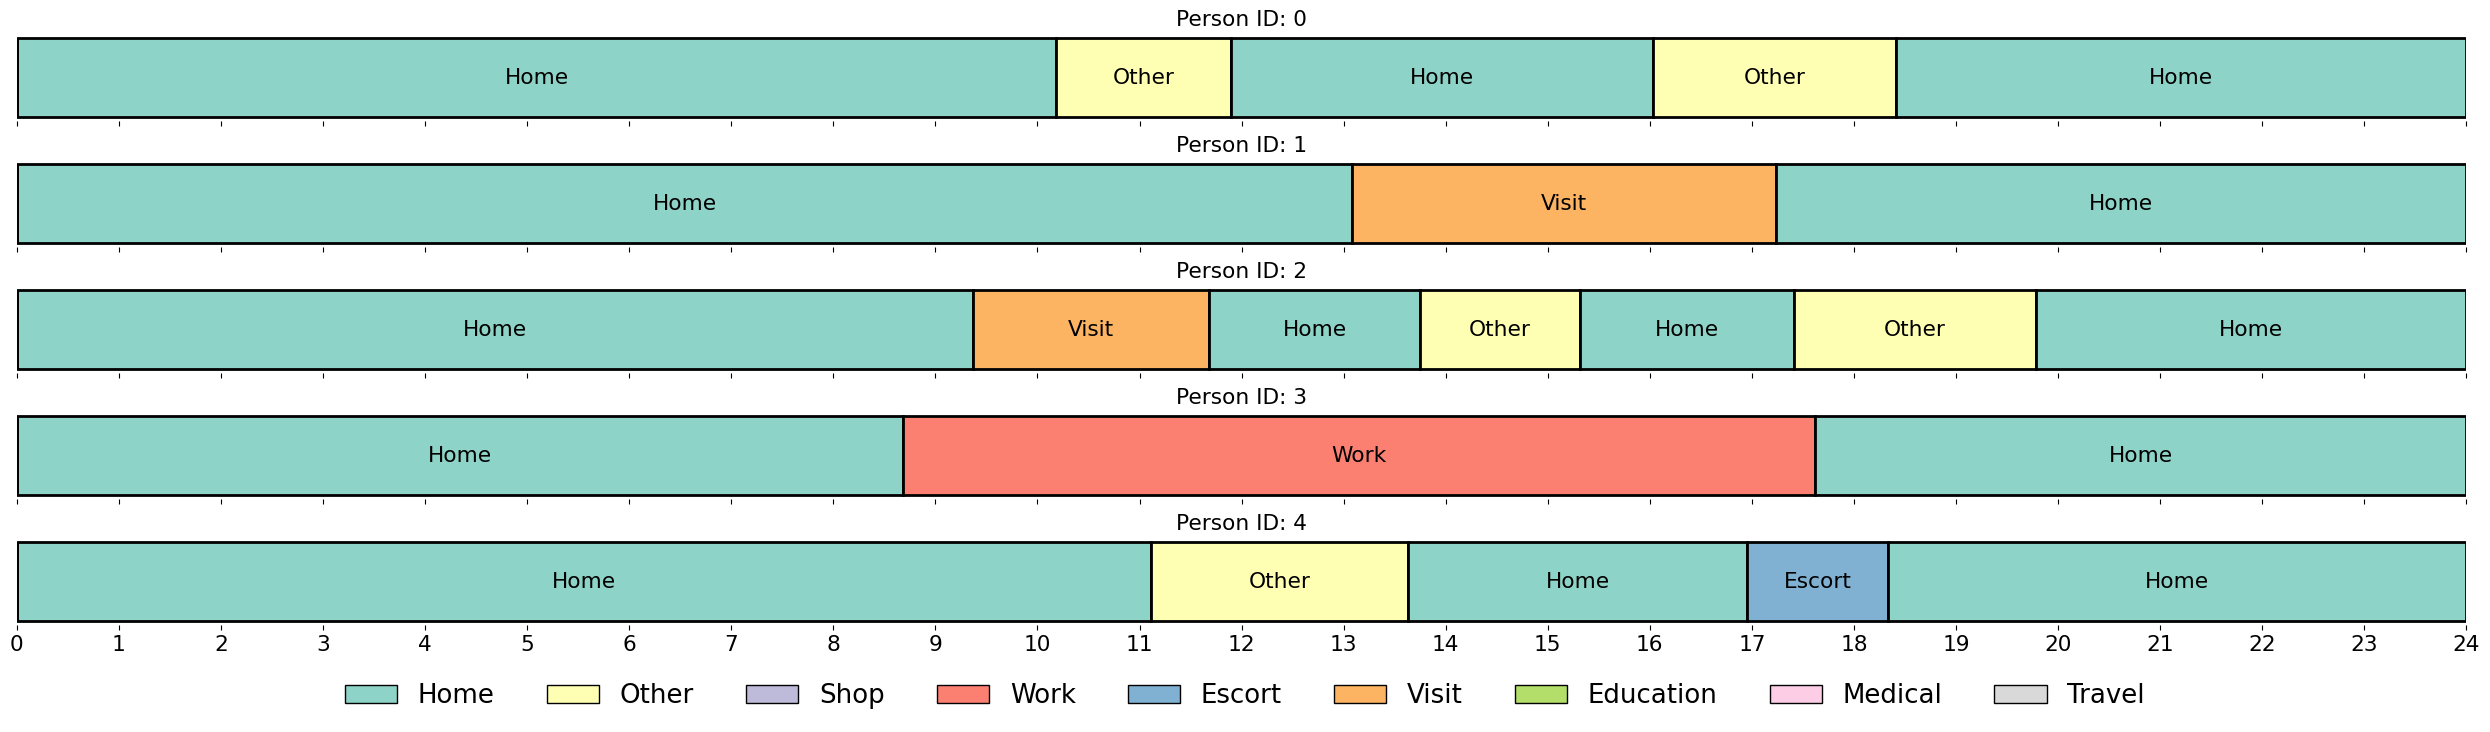

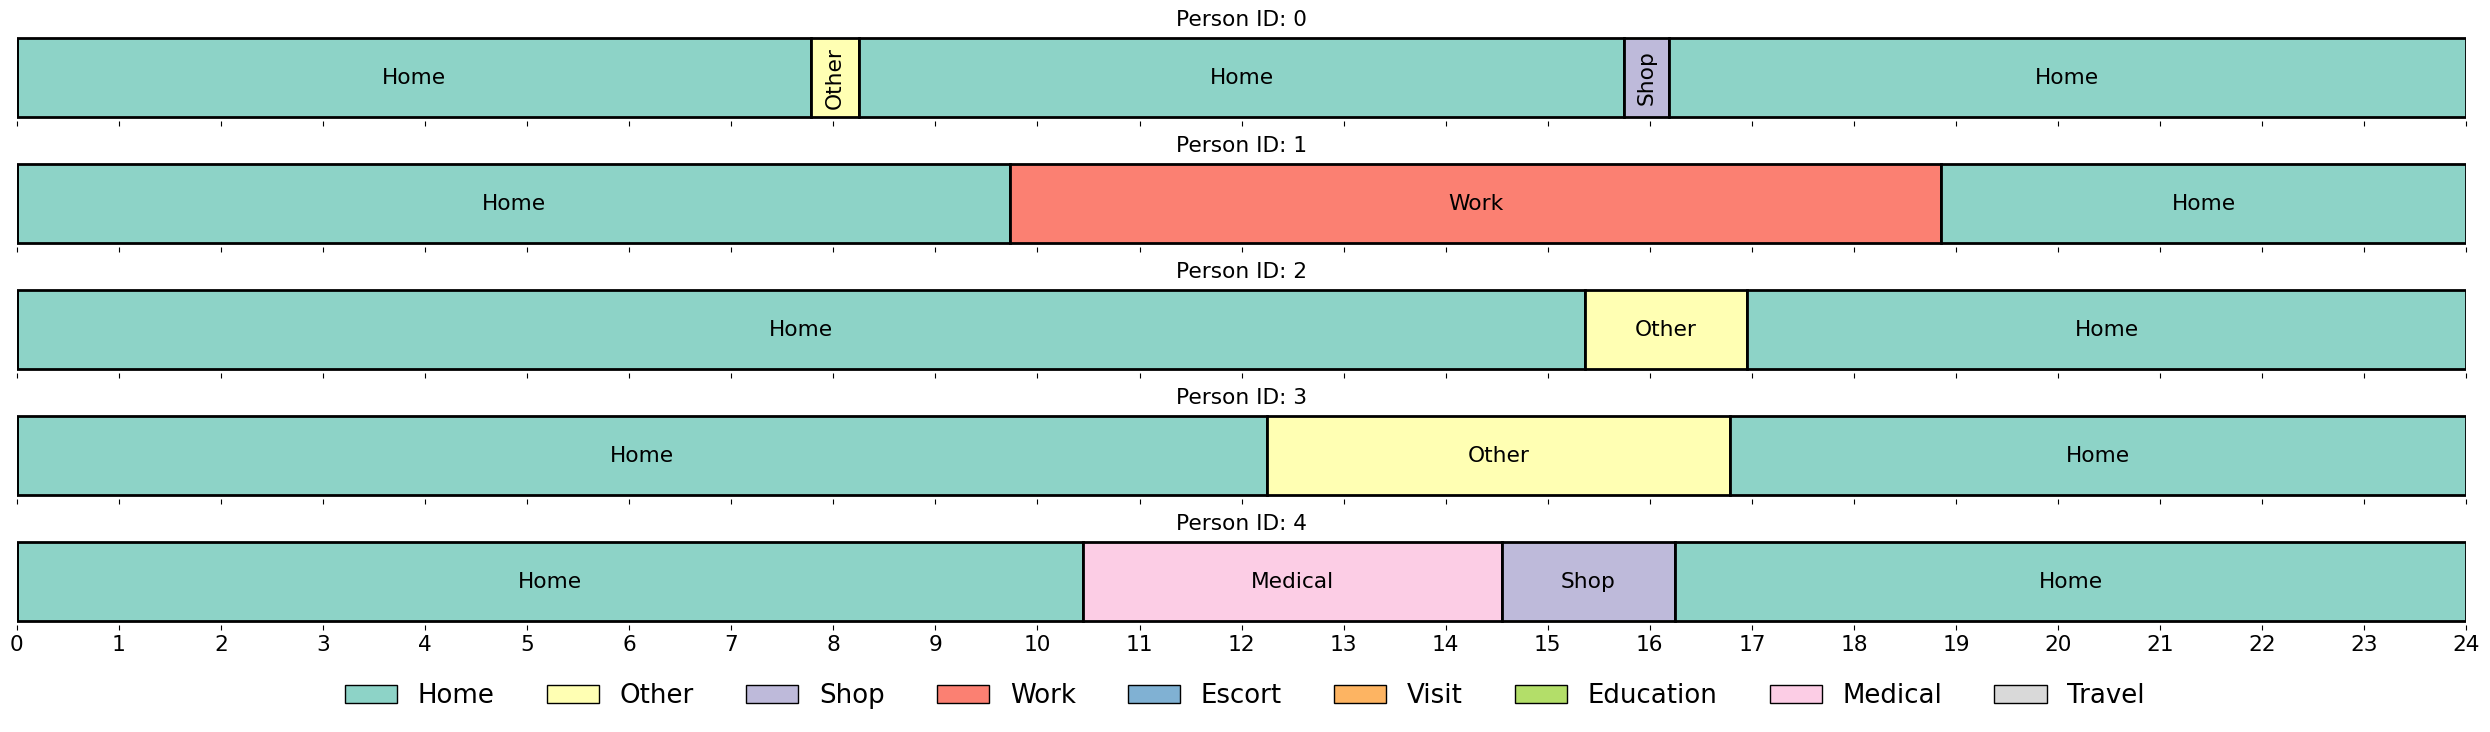

In [ ]:
for n, p in batch_paths.items():
    examples = pd.read_csv(next(find_nth(p))[1] / "synthetic_schedules.csv")
    plot_schedules(examples)